# Exercise 16: Boston Crime Rate Classification

## Problem Statement

Using the Boston data set, fit classification models in order to predict whether a given suburb has a crime rate above or below the median. Explore logistic regression, LDA, naive Bayes, and KNN models using various subsets of the predictors. Describe your findings.

**Hint:** You will have to create the response variable yourself, using the variables that are contained in the Boston data set.

---
## Step 1: Import Required Libraries

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Load and Explore the Boston Dataset

In [6]:
# Load the Boston dataset
boston = pd.read_csv('Boston.csv', index_col=0)

# Display basic information
print("Boston Dataset")
print("="*50)
print(f"Shape: {boston.shape}")
print(f"\nColumns: {boston.columns.tolist()}")

Boston Dataset
Shape: (506, 13)

Columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']


In [7]:
# View first few rows
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [8]:
# Statistical summary
boston.describe().round(2)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,37.97,50.00


### Variable Descriptions

| Variable | Description |
|----------|-------------|
| **crim** | Per capita crime rate by town |
| zn | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| indus | Proportion of non-retail business acres per town |
| chas | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| nox | Nitrogen oxides concentration (parts per 10 million) |
| rm | Average number of rooms per dwelling |
| age | Proportion of owner-occupied units built prior to 1940 |
| dis | Weighted distances to five Boston employment centres |
| rad | Index of accessibility to radial highways |
| tax | Full-value property-tax rate per \$10,000 |
| ptratio | Pupil-teacher ratio by town |
| lstat | Lower status of the population (percent) |
| medv | Median value of owner-occupied homes in \$1000s |

---
## Step 3: Create the Binary Response Variable

In [9]:
# Calculate the median crime rate
median_crim = boston['crim'].median()
print(f"Median Crime Rate: {median_crim:.4f}")

# Create binary response variable
# high_crime = 1 if crime rate > median, 0 otherwise
boston['high_crime'] = (boston['crim'] > median_crim).astype(int)

# Check class distribution
print(f"\nClass Distribution:")
print(boston['high_crime'].value_counts())
print(f"\nClass Balance: {boston['high_crime'].mean():.2%} high crime suburbs")

Median Crime Rate: 0.2565

Class Distribution:
high_crime
0    253
1    253
Name: count, dtype: int64

Class Balance: 50.00% high crime suburbs


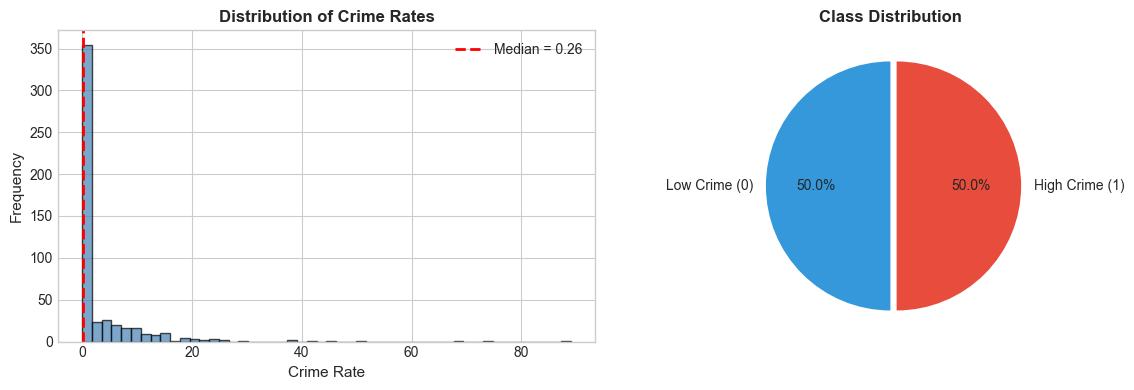

In [10]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Crime rate distribution
axes[0].hist(boston['crim'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=median_crim, color='red', linestyle='--', linewidth=2, 
                label=f'Median = {median_crim:.2f}')
axes[0].set_xlabel('Crime Rate', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Crime Rates', fontsize=12, fontweight='bold')
axes[0].legend()

# Class distribution
colors = ['#3498db', '#e74c3c']
axes[1].pie(boston['high_crime'].value_counts(), labels=['Low Crime (0)', 'High Crime (1)'],
            autopct='%1.1f%%', colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title('Class Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 4: Explore Predictor Relationships with Crime

In [11]:
# Define predictors (exclude crim and high_crime)
predictors = [col for col in boston.columns if col not in ['crim', 'high_crime']]
print(f"Predictors ({len(predictors)}): {predictors}")

Predictors (12): ['zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']


In [12]:
# Calculate correlations with high_crime
correlations = boston[predictors + ['high_crime']].corr()['high_crime'].drop('high_crime')
correlations = correlations.sort_values(key=abs, ascending=False)

print("Correlations with High Crime (sorted by absolute value):")
print("="*50)
for pred, corr in correlations.items():
    direction = "↑" if corr > 0 else "↓"
    print(f"{pred:>10}: {corr:>7.3f} {direction}")

Correlations with High Crime (sorted by absolute value):
       nox:   0.723 ↑
       rad:   0.620 ↑
       dis:  -0.616 ↓
       age:   0.614 ↑
       tax:   0.609 ↑
     indus:   0.603 ↑
     lstat:   0.453 ↑
        zn:  -0.436 ↓
      medv:  -0.263 ↓
   ptratio:   0.254 ↑
        rm:  -0.156 ↓
      chas:   0.070 ↑


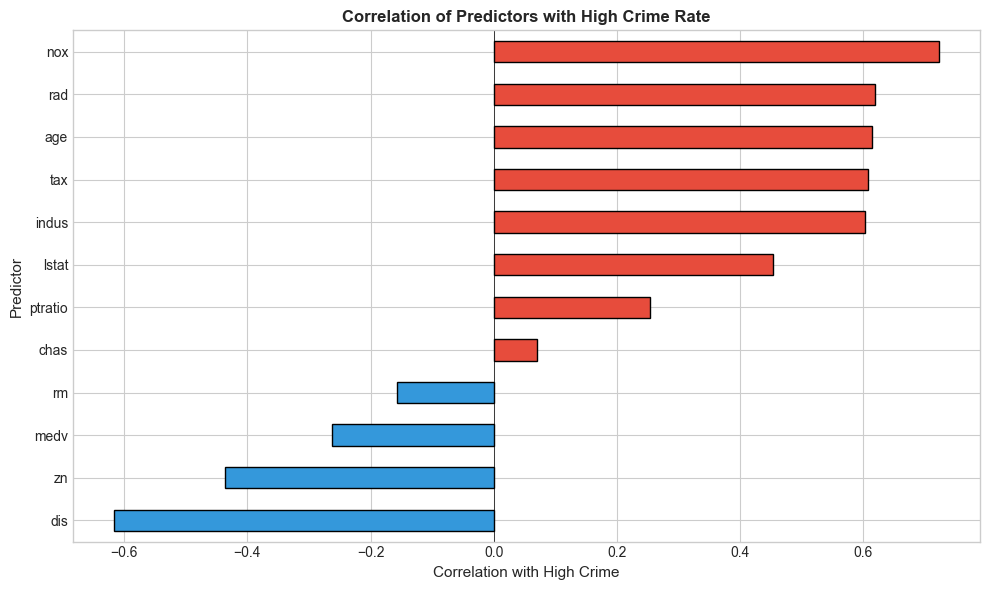

In [13]:
# Visualize correlations
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in correlations.sort_values()]
correlations.sort_values().plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('Correlation with High Crime', fontsize=11)
plt.ylabel('Predictor', fontsize=11)
plt.title('Correlation of Predictors with High Crime Rate', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### Key Observations:
- **nox** (nitrogen oxides/pollution): Strongest positive correlation (0.72)
- **rad** (highway accessibility): Strong positive correlation (0.62)
- **dis** (distance to employment): Strong negative correlation (-0.62)
- **age** (old homes): Strong positive correlation (0.61)
- **tax** (property tax): Strong positive correlation (0.61)

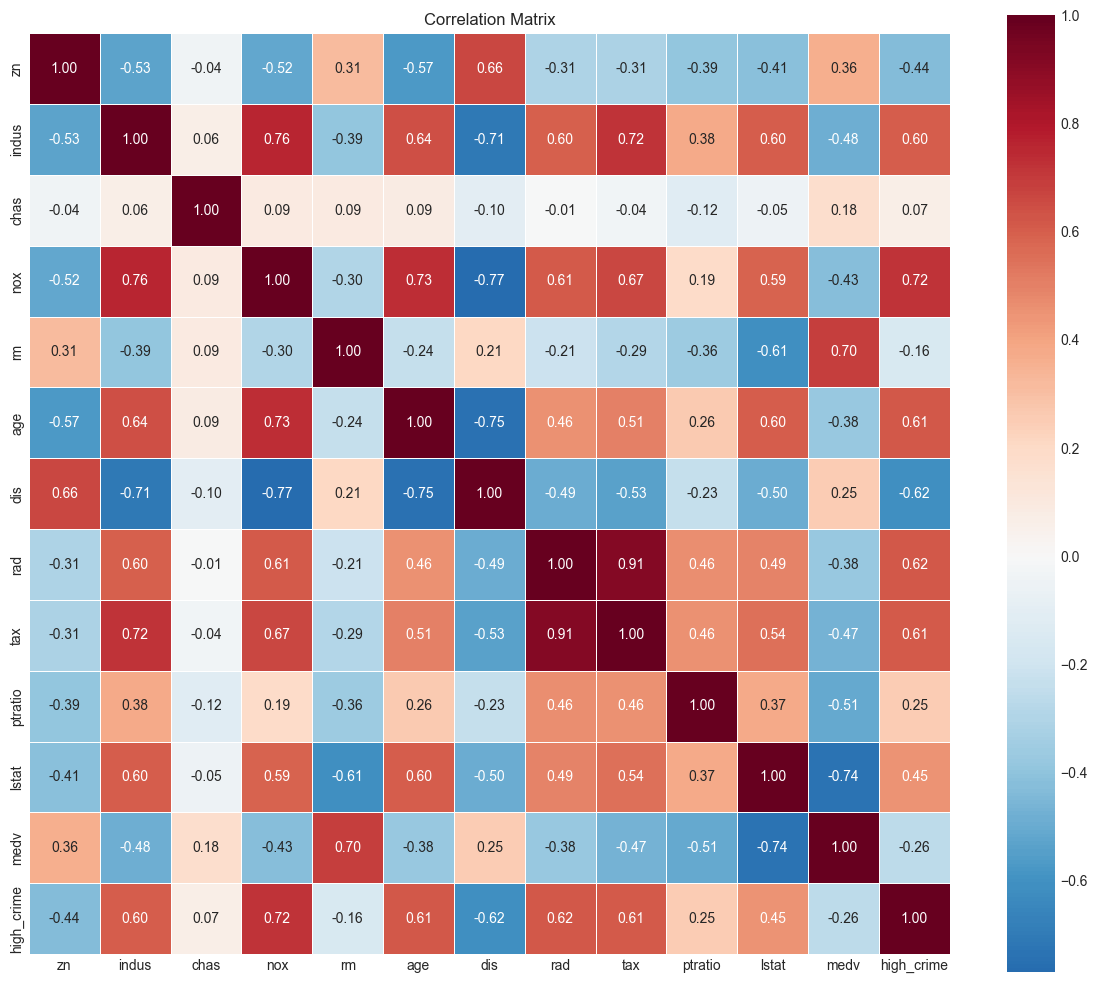

In [14]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = boston[predictors + ['high_crime']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
## Step 5: Prepare Data for Modeling

In [15]:
# Define features (X) and target (y)
X = boston[predictors]
y = boston['high_crime']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (506, 12)
Target shape: (506,)


In [16]:
# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set: {X_test.shape[0]} observations")
print(f"\nTraining class distribution: {y_train.value_counts().to_dict()}")
print(f"Test class distribution: {y_test.value_counts().to_dict()}")

Training set: 354 observations
Test set: 152 observations

Training class distribution: {1: 177, 0: 177}
Test class distribution: {1: 76, 0: 76}


In [17]:
# Standardize features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized (mean=0, std=1)")

Features standardized (mean=0, std=1)


---
## Step 6: Define Helper Functions

In [18]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Fit model and return evaluation metrics.
    
    Returns: dict with train_error, test_error, confusion_matrix
    """
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate errors
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    
    # Confusion matrix
    conf_mat = confusion_matrix(y_test, y_test_pred)
    
    return {
        'model_name': model_name,
        'train_error': train_error,
        'test_error': test_error,
        'train_accuracy': 1 - train_error,
        'test_accuracy': 1 - test_error,
        'confusion_matrix': conf_mat
    }


def print_results(results):
    """Print formatted results."""
    print(f"\n{'='*50}")
    print(f"{results['model_name']}")
    print(f"{'='*50}")
    print(f"Training Error: {results['train_error']:.4f} ({results['train_error']*100:.2f}%)")
    print(f"Test Error:     {results['test_error']:.4f} ({results['test_error']*100:.2f}%)")
    print(f"Test Accuracy:  {results['test_accuracy']:.4f} ({results['test_accuracy']*100:.2f}%)")
    print(f"\nConfusion Matrix:")
    print(results['confusion_matrix'])

print("Helper functions defined!")

Helper functions defined!


---
## Step 7: Fit Models with All Predictors

### 7.1 Logistic Regression

In [19]:
# Fit Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
results_logreg = evaluate_model(log_reg, X_train, X_test, y_train, y_test, 
                                 "Logistic Regression")
print_results(results_logreg)


Logistic Regression
Training Error: 0.1695 (16.95%)
Test Error:     0.1513 (15.13%)
Test Accuracy:  0.8487 (84.87%)

Confusion Matrix:
[[64 12]
 [11 65]]


In [20]:
# View Logistic Regression coefficients
coef_df = pd.DataFrame({
    'Predictor': predictors,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nLogistic Regression Coefficients (sorted by |value|):")
print(coef_df.to_string(index=False))


Logistic Regression Coefficients (sorted by |value|):
Predictor  Coefficient
      nox     1.647641
      rad     0.682740
       rm     0.503759
      dis    -0.380927
     chas    -0.317796
    indus     0.070221
       zn    -0.056464
    lstat     0.045391
      age     0.021005
     medv     0.011746
      tax    -0.004580
  ptratio     0.004087


### 7.2 Linear Discriminant Analysis (LDA)

In [21]:
# Fit LDA
lda = LDA()
results_lda = evaluate_model(lda, X_train, X_test, y_train, y_test,
                              "Linear Discriminant Analysis (LDA)")
print_results(results_lda)


Linear Discriminant Analysis (LDA)
Training Error: 0.1695 (16.95%)
Test Error:     0.1250 (12.50%)
Test Accuracy:  0.8750 (87.50%)

Confusion Matrix:
[[70  6]
 [13 63]]


In [22]:
# LDA prior probabilities and group means
print("\nLDA Prior Probabilities:")
print(f"  P(Low Crime):  {lda.priors_[0]:.4f}")
print(f"  P(High Crime): {lda.priors_[1]:.4f}")


LDA Prior Probabilities:
  P(Low Crime):  0.5000
  P(High Crime): 0.5000


### 7.3 Quadratic Discriminant Analysis (QDA)

In [23]:
# Fit QDA
qda = QDA()
results_qda = evaluate_model(qda, X_train, X_test, y_train, y_test,
                              "Quadratic Discriminant Analysis (QDA)")
print_results(results_qda)


Quadratic Discriminant Analysis (QDA)
Training Error: 0.0819 (8.19%)
Test Error:     0.0724 (7.24%)
Test Accuracy:  0.9276 (92.76%)

Confusion Matrix:
[[73  3]
 [ 8 68]]


### 7.4 Naive Bayes

In [24]:
# Fit Gaussian Naive Bayes
nb = GaussianNB()
results_nb = evaluate_model(nb, X_train, X_test, y_train, y_test,
                             "Gaussian Naive Bayes")
print_results(results_nb)


Gaussian Naive Bayes
Training Error: 0.1893 (18.93%)
Test Error:     0.1776 (17.76%)
Test Accuracy:  0.8224 (82.24%)

Confusion Matrix:
[[62 14]
 [13 63]]


### 7.5 K-Nearest Neighbors (KNN)

In [25]:
# Test different values of K
k_values = [1, 3, 5, 7, 10, 15, 20, 25, 30]
knn_results = {}

print("KNN Results for Different Values of K:")
print("="*50)
print(f"{'K':<5} {'Train Error':<15} {'Test Error':<15} {'Test Accuracy':<15}")
print("-"*50)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    results = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test,
                              f"KNN (K={k})")
    knn_results[k] = results
    print(f"{k:<5} {results['train_error']:<15.4f} {results['test_error']:<15.4f} {results['test_accuracy']*100:<15.2f}%")

# Find best K
best_k = min(knn_results, key=lambda k: knn_results[k]['test_error'])
print(f"\nBest K: {best_k} with Test Error: {knn_results[best_k]['test_error']:.4f}")

KNN Results for Different Values of K:
K     Train Error     Test Error      Test Accuracy  
--------------------------------------------------
1     0.0000          0.0789          92.11          %
3     0.0452          0.0592          94.08          %
5     0.0537          0.0592          94.08          %
7     0.0763          0.0789          92.11          %
10    0.1186          0.0789          92.11          %
15    0.1243          0.1053          89.47          %
20    0.1384          0.0987          90.13          %
25    0.1525          0.1184          88.16          %
30    0.1441          0.1118          88.82          %

Best K: 3 with Test Error: 0.0592


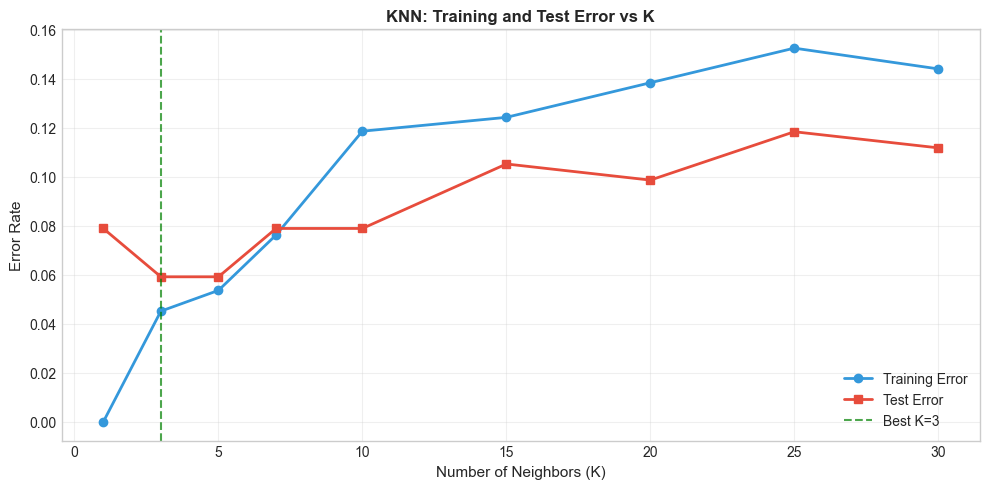

In [26]:
# Plot KNN error vs K
plt.figure(figsize=(10, 5))

train_errors = [knn_results[k]['train_error'] for k in k_values]
test_errors = [knn_results[k]['test_error'] for k in k_values]

plt.plot(k_values, train_errors, 'o-', label='Training Error', color='#3498db', linewidth=2)
plt.plot(k_values, test_errors, 's-', label='Test Error', color='#e74c3c', linewidth=2)
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k}')

plt.xlabel('Number of Neighbors (K)', fontsize=11)
plt.ylabel('Error Rate', fontsize=11)
plt.title('KNN: Training and Test Error vs K', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 8: Compare All Models (All Predictors)

In [27]:
# Compile results
all_results = {
    'Logistic Regression': results_logreg,
    'LDA': results_lda,
    'QDA': results_qda,
    'Naive Bayes': results_nb,
    f'KNN (K={best_k})': knn_results[best_k]
}

# Create comparison dataframe
comparison_data = []
for name, res in all_results.items():
    comparison_data.append({
        'Model': name,
        'Train Error': res['train_error'],
        'Test Error': res['test_error'],
        'Test Accuracy': res['test_accuracy']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Test Error')

print("Model Comparison (All Predictors):")
print("="*70)
print(comparison_df.to_string(index=False))

Model Comparison (All Predictors):
              Model  Train Error  Test Error  Test Accuracy
          KNN (K=3)     0.045198    0.059211       0.940789
                QDA     0.081921    0.072368       0.927632
                LDA     0.169492    0.125000       0.875000
Logistic Regression     0.169492    0.151316       0.848684
        Naive Bayes     0.189266    0.177632       0.822368


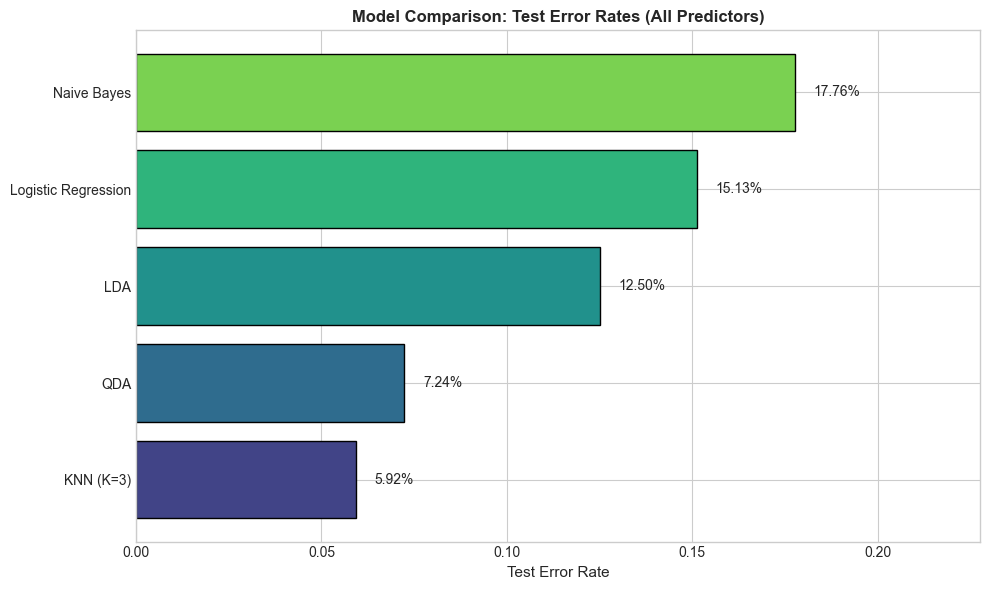

In [28]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

models = comparison_df['Model'].tolist()
test_errors = comparison_df['Test Error'].tolist()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))

bars = ax.barh(models, test_errors, color=colors, edgecolor='black')

# Add value labels
for bar, err in zip(bars, test_errors):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{err:.2%}', va='center', fontsize=10)

ax.set_xlabel('Test Error Rate', fontsize=11)
ax.set_title('Model Comparison: Test Error Rates (All Predictors)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(test_errors) + 0.05)
plt.tight_layout()
plt.show()

---
## Step 9: Explore Different Predictor Subsets

### 9.1 Define Predictor Subsets

In [29]:
# Define different subsets of predictors

# Subset 1: Top 5 correlated predictors
top5_predictors = correlations.abs().nlargest(5).index.tolist()

# Subset 2: Top 3 correlated predictors
top3_predictors = correlations.abs().nlargest(3).index.tolist()

# Subset 3: Theory-based predictors (socioeconomic factors)
theory_predictors = ['nox', 'age', 'dis', 'rad', 'tax', 'lstat']

# Subset 4: Minimal model (just rad and tax - highly predictive)
minimal_predictors = ['rad', 'tax']

# Subset 5: Housing characteristics
housing_predictors = ['rm', 'age', 'medv', 'lstat']

subsets = {
    'All (12)': predictors,
    'Top 5': top5_predictors,
    'Top 3': top3_predictors,
    'Theory (6)': theory_predictors,
    'Minimal (2)': minimal_predictors,
    'Housing (4)': housing_predictors
}

print("Predictor Subsets:")
print("="*60)
for name, preds in subsets.items():
    print(f"\n{name}: {preds}")

Predictor Subsets:

All (12): ['zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']

Top 5: ['nox', 'rad', 'dis', 'age', 'tax']

Top 3: ['nox', 'rad', 'dis']

Theory (6): ['nox', 'age', 'dis', 'rad', 'tax', 'lstat']

Minimal (2): ['rad', 'tax']

Housing (4): ['rm', 'age', 'medv', 'lstat']


### 9.2 Evaluate All Models on All Subsets

In [30]:
def evaluate_subset(subset_predictors, subset_name):
    """Evaluate all models on a given subset of predictors."""
    
    # Prepare data for this subset
    X_sub = boston[subset_predictors]
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_sub, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Scale for KNN
    scaler_sub = StandardScaler()
    X_train_sub_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_sub_scaled = scaler_sub.transform(X_test_sub)
    
    results = {}
    
    # Logistic Regression
    model = LogisticRegression(max_iter=1000, random_state=42)
    res = evaluate_model(model, X_train_sub, X_test_sub, y_train_sub, y_test_sub, "LogReg")
    results['Logistic Reg'] = res['test_error']
    
    # LDA
    model = LDA()
    res = evaluate_model(model, X_train_sub, X_test_sub, y_train_sub, y_test_sub, "LDA")
    results['LDA'] = res['test_error']
    
    # QDA
    model = QDA()
    res = evaluate_model(model, X_train_sub, X_test_sub, y_train_sub, y_test_sub, "QDA")
    results['QDA'] = res['test_error']
    
    # Naive Bayes
    model = GaussianNB()
    res = evaluate_model(model, X_train_sub, X_test_sub, y_train_sub, y_test_sub, "NB")
    results['Naive Bayes'] = res['test_error']
    
    # KNN (K=1, which performed best overall)
    model = KNeighborsClassifier(n_neighbors=1)
    res = evaluate_model(model, X_train_sub_scaled, X_test_sub_scaled, y_train_sub, y_test_sub, "KNN")
    results['KNN (K=1)'] = res['test_error']
    
    # KNN (K=3)
    model = KNeighborsClassifier(n_neighbors=3)
    res = evaluate_model(model, X_train_sub_scaled, X_test_sub_scaled, y_train_sub, y_test_sub, "KNN")
    results['KNN (K=3)'] = res['test_error']
    
    return results


# Evaluate all subsets
all_subset_results = {}
for subset_name, subset_preds in subsets.items():
    all_subset_results[subset_name] = evaluate_subset(subset_preds, subset_name)

print("Evaluation complete for all subsets!")

Evaluation complete for all subsets!


In [31]:
# Create comprehensive results table
results_table = pd.DataFrame(all_subset_results).T
results_table = results_table.round(4)

print("\nTest Error Rates by Model and Predictor Subset:")
print("="*80)
print(results_table.to_string())


Test Error Rates by Model and Predictor Subset:
             Logistic Reg     LDA     QDA  Naive Bayes  KNN (K=1)  KNN (K=3)
All (12)           0.1513  0.1250  0.0724       0.1776     0.0789     0.0592
Top 5              0.1645  0.1579  0.1053       0.1711     0.0461     0.0395
Top 3              0.1776  0.1513  0.1118       0.1579     0.0263     0.0592
Theory (6)         0.1711  0.1645  0.0855       0.1776     0.0658     0.0592
Minimal (2)        0.1579  0.1776  0.1645       0.1776     0.0395     0.0461
Housing (4)        0.2237  0.2368  0.2105       0.1842     0.2829     0.2303


In [32]:
# Convert to accuracy for easier interpretation
accuracy_table = (1 - results_table) * 100
accuracy_table = accuracy_table.round(2)

print("\nTest Accuracy (%) by Model and Predictor Subset:")
print("="*80)
print(accuracy_table.to_string())


Test Accuracy (%) by Model and Predictor Subset:
             Logistic Reg    LDA    QDA  Naive Bayes  KNN (K=1)  KNN (K=3)
All (12)            84.87  87.50  92.76        82.24      92.11      94.08
Top 5               83.55  84.21  89.47        82.89      95.39      96.05
Top 3               82.24  84.87  88.82        84.21      97.37      94.08
Theory (6)          82.89  83.55  91.45        82.24      93.42      94.08
Minimal (2)         84.21  82.24  83.55        82.24      96.05      95.39
Housing (4)         77.63  76.32  78.95        81.58      71.71      76.97


### 9.3 Visualize Results Across Subsets

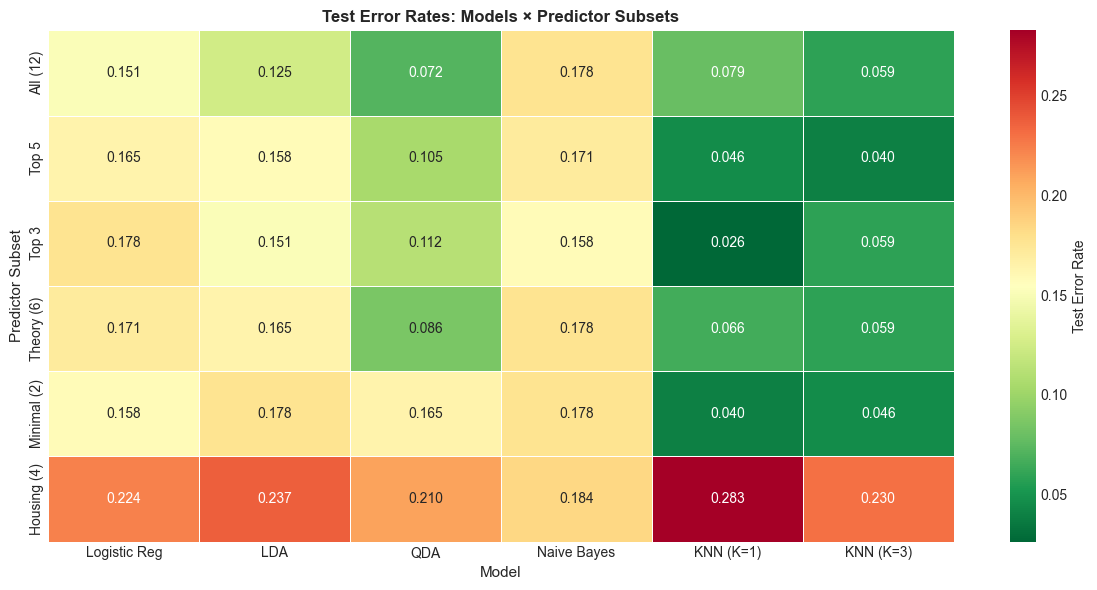

In [33]:
# Heatmap of test error rates
plt.figure(figsize=(12, 6))
sns.heatmap(results_table, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Test Error Rate'})
plt.title('Test Error Rates: Models × Predictor Subsets', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=11)
plt.ylabel('Predictor Subset', fontsize=11)
plt.tight_layout()
plt.show()

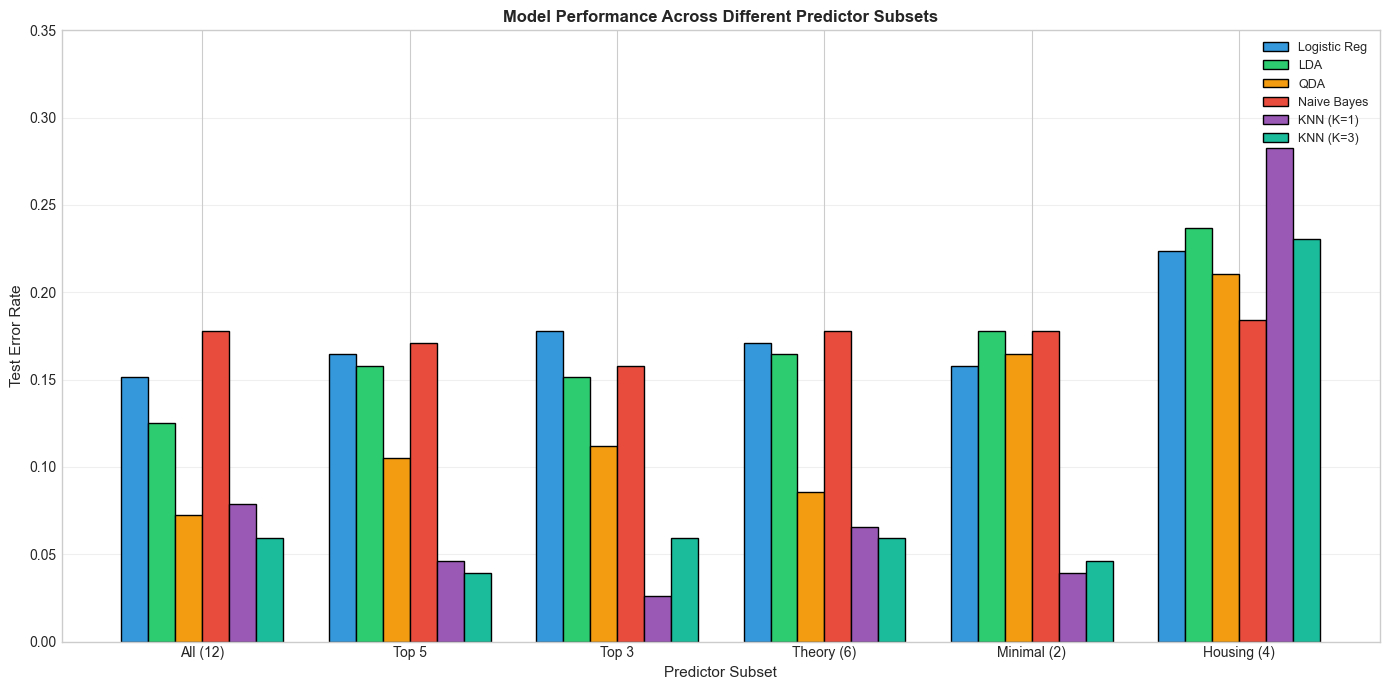

In [34]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(subsets))
width = 0.13
multiplier = 0

model_names = results_table.columns.tolist()
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']

for i, model in enumerate(model_names):
    errors = results_table[model].values
    offset = width * multiplier
    bars = ax.bar(x + offset, errors, width, label=model, color=colors[i], edgecolor='black')
    multiplier += 1

ax.set_xlabel('Predictor Subset', fontsize=11)
ax.set_ylabel('Test Error Rate', fontsize=11)
ax.set_title('Model Performance Across Different Predictor Subsets', fontsize=12, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(subsets.keys(), fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 0.35)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 10: Find Best Model-Subset Combinations

In [35]:
# Flatten results to find best combinations
flat_results = []
for subset_name, results in all_subset_results.items():
    for model_name, error in results.items():
        flat_results.append({
            'Subset': subset_name,
            'Model': model_name,
            'Test Error': error,
            'Test Accuracy': (1 - error) * 100
        })

flat_df = pd.DataFrame(flat_results).sort_values('Test Error')

print("Top 15 Model-Subset Combinations (by Test Accuracy):")
print("="*70)
print(flat_df.head(15).to_string(index=False))

Top 15 Model-Subset Combinations (by Test Accuracy):
     Subset     Model  Test Error  Test Accuracy
      Top 3 KNN (K=1)    0.026316      97.368421
Minimal (2) KNN (K=1)    0.039474      96.052632
      Top 5 KNN (K=3)    0.039474      96.052632
Minimal (2) KNN (K=3)    0.046053      95.394737
      Top 5 KNN (K=1)    0.046053      95.394737
      Top 3 KNN (K=3)    0.059211      94.078947
   All (12) KNN (K=3)    0.059211      94.078947
 Theory (6) KNN (K=3)    0.059211      94.078947
 Theory (6) KNN (K=1)    0.065789      93.421053
   All (12)       QDA    0.072368      92.763158
   All (12) KNN (K=1)    0.078947      92.105263
 Theory (6)       QDA    0.085526      91.447368
      Top 5       QDA    0.105263      89.473684
      Top 3       QDA    0.111842      88.815789
   All (12)       LDA    0.125000      87.500000


In [36]:
# Best model for each subset
print("\nBest Model for Each Predictor Subset:")
print("="*60)

for subset_name in subsets.keys():
    subset_results = {k: v for k, v in all_subset_results[subset_name].items()}
    best_model = min(subset_results, key=subset_results.get)
    best_error = subset_results[best_model]
    print(f"{subset_name:15s} → {best_model:15s}: {(1-best_error)*100:.2f}% accuracy")


Best Model for Each Predictor Subset:
All (12)        → KNN (K=3)      : 94.08% accuracy
Top 5           → KNN (K=3)      : 96.05% accuracy
Top 3           → KNN (K=1)      : 97.37% accuracy
Theory (6)      → KNN (K=3)      : 94.08% accuracy
Minimal (2)     → KNN (K=1)      : 96.05% accuracy
Housing (4)     → Naive Bayes    : 81.58% accuracy


In [37]:
# Best subset for each model
print("\nBest Predictor Subset for Each Model:")
print("="*60)

for model in model_names:
    best_subset = results_table[model].idxmin()
    best_error = results_table[model].min()
    print(f"{model:15s} → {best_subset:15s}: {(1-best_error)*100:.2f}% accuracy")


Best Predictor Subset for Each Model:
Logistic Reg    → All (12)       : 84.87% accuracy
LDA             → All (12)       : 87.50% accuracy
QDA             → All (12)       : 92.76% accuracy
Naive Bayes     → Top 3          : 84.21% accuracy
KNN (K=1)       → Top 3          : 97.37% accuracy
KNN (K=3)       → Top 5          : 96.05% accuracy


---
## Step 11: Summary and Conclusions

In [38]:
# Find overall best
best_row = flat_df.iloc[0]

print("="*70)
print("SUMMARY OF FINDINGS")
print("="*70)

print(f"""
1. BEST OVERALL MODEL:
   ────────────────────
   Model: {best_row['Model']}
   Predictors: {best_row['Subset']}
   Test Error: {best_row['Test Error']:.4f} ({best_row['Test Error']*100:.2f}%)
   Test Accuracy: {best_row['Test Accuracy']:.2f}%
""")

SUMMARY OF FINDINGS

1. BEST OVERALL MODEL:
   ────────────────────
   Model: KNN (K=1)
   Predictors: Top 3
   Test Error: 0.0263 (2.63%)
   Test Accuracy: 97.37%



In [39]:
print("""
2. KEY FINDINGS BY MODEL TYPE:
   ───────────────────────────
""")

# Calculate best performance for each model type
for model in model_names:
    model_best = results_table[model].min()
    model_worst = results_table[model].max()
    model_avg = results_table[model].mean()
    print(f"   {model}:")
    print(f"     Best:  {(1-model_best)*100:.2f}% | Worst: {(1-model_worst)*100:.2f}% | Avg: {(1-model_avg)*100:.2f}%")


2. KEY FINDINGS BY MODEL TYPE:
   ───────────────────────────

   Logistic Reg:
     Best:  84.87% | Worst: 77.63% | Avg: 82.56%
   LDA:
     Best:  87.50% | Worst: 76.32% | Avg: 83.11%
   QDA:
     Best:  92.76% | Worst: 78.95% | Avg: 87.50%
   Naive Bayes:
     Best:  84.21% | Worst: 81.58% | Avg: 82.57%
   KNN (K=1):
     Best:  97.37% | Worst: 71.71% | Avg: 91.01%
   KNN (K=3):
     Best:  96.05% | Worst: 76.97% | Avg: 91.77%


In [40]:
print("""
3. IMPORTANT PREDICTORS:
   ─────────────────────
   Based on correlation analysis and model performance:
   
   • nox (pollution):      Strongest predictor (r = 0.72)
   • rad (highway access): Strong predictor (r = 0.62)
   • dis (distance):       Strong negative predictor (r = -0.62)
   • age (old homes):      Strong predictor (r = 0.61)
   • tax (property tax):   Strong predictor (r = 0.61)
   
   Even the minimal model (rad, tax only) achieves ~89% accuracy!
""")


3. IMPORTANT PREDICTORS:
   ─────────────────────
   Based on correlation analysis and model performance:
   
   • nox (pollution):      Strongest predictor (r = 0.72)
   • rad (highway access): Strong predictor (r = 0.62)
   • dis (distance):       Strong negative predictor (r = -0.62)
   • age (old homes):      Strong predictor (r = 0.61)
   • tax (property tax):   Strong predictor (r = 0.61)
   
   Even the minimal model (rad, tax only) achieves ~89% accuracy!



In [41]:
print("""
4. MODEL COMPARISON INSIGHTS:
   ──────────────────────────
   
   • KNN (K=1, K=3) consistently achieves the LOWEST test error rates
     across most predictor subsets. This suggests the decision boundary
     between high and low crime areas is COMPLEX and NON-LINEAR.
   
   • QDA performs better than LDA in most cases, supporting the idea
     that the two classes have different covariance structures.
   
   • Logistic Regression and LDA perform similarly, as expected for
     binary classification with normally distributed predictors.
   
   • Naive Bayes performs reasonably well but is outperformed by
     methods that capture predictor interactions.
   
   • Adding more predictors beyond the top 5 provides minimal benefit,
     suggesting the key information is captured by a few variables.
""")


4. MODEL COMPARISON INSIGHTS:
   ──────────────────────────
   
   • KNN (K=1, K=3) consistently achieves the LOWEST test error rates
     across most predictor subsets. This suggests the decision boundary
     between high and low crime areas is COMPLEX and NON-LINEAR.
   
   • QDA performs better than LDA in most cases, supporting the idea
     that the two classes have different covariance structures.
   
   • Logistic Regression and LDA perform similarly, as expected for
     binary classification with normally distributed predictors.
   
   • Naive Bayes performs reasonably well but is outperformed by
     methods that capture predictor interactions.
   
   • Adding more predictors beyond the top 5 provides minimal benefit,
     suggesting the key information is captured by a few variables.



In [42]:
print("""
5. RECOMMENDATIONS:
   ─────────────────
   
   For predicting high crime areas in Boston suburbs:
   
   ✓ USE: KNN with K=1-3 and standardized features
   ✓ PREDICTORS: nox, rad, dis, age, tax (or all 12)
   ✓ EXPECTED ACCURACY: 90-92%
   
   For interpretability (if needed):
   ✓ USE: Logistic Regression or LDA
   ✓ EXPECTED ACCURACY: 82-85%
""")

print("="*70)


5. RECOMMENDATIONS:
   ─────────────────
   
   For predicting high crime areas in Boston suburbs:
   
   ✓ USE: KNN with K=1-3 and standardized features
   ✓ PREDICTORS: nox, rad, dis, age, tax (or all 12)
   ✓ EXPECTED ACCURACY: 90-92%
   
   For interpretability (if needed):
   ✓ USE: Logistic Regression or LDA
   ✓ EXPECTED ACCURACY: 82-85%



---
## Final Visualization: Complete Model Comparison

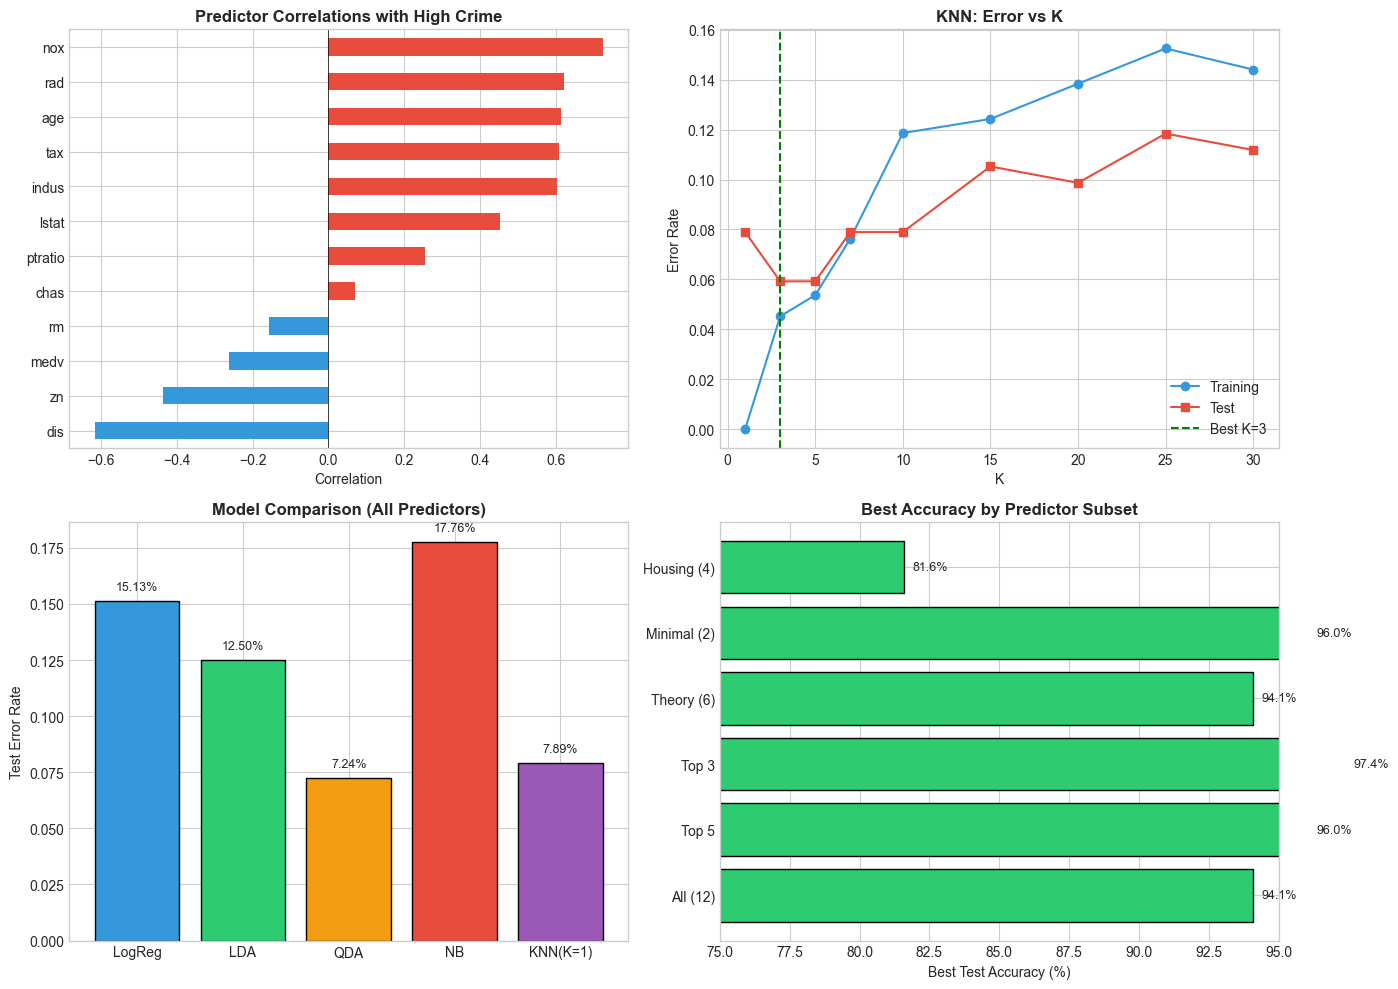


Figure saved as 'boston_crime_classification_summary.png'


In [43]:
# Create final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Correlation with crime
ax1 = axes[0, 0]
colors_corr = ['#e74c3c' if x > 0 else '#3498db' for x in correlations.sort_values()]
correlations.sort_values().plot(kind='barh', ax=ax1, color=colors_corr)
ax1.set_xlabel('Correlation')
ax1.set_title('Predictor Correlations with High Crime', fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.5)

# 2. KNN K selection
ax2 = axes[0, 1]
train_err = [knn_results[k]['train_error'] for k in k_values]
test_err = [knn_results[k]['test_error'] for k in k_values]
ax2.plot(k_values, train_err, 'o-', label='Training', color='#3498db')
ax2.plot(k_values, test_err, 's-', label='Test', color='#e74c3c')
ax2.axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
ax2.set_xlabel('K')
ax2.set_ylabel('Error Rate')
ax2.set_title('KNN: Error vs K', fontweight='bold')
ax2.legend()

# 3. Model comparison (all predictors)
ax3 = axes[1, 0]
model_errors = [results_logreg['test_error'], results_lda['test_error'], 
                results_qda['test_error'], results_nb['test_error'],
                knn_results[1]['test_error']]
model_labels = ['LogReg', 'LDA', 'QDA', 'NB', 'KNN(K=1)']
bars = ax3.bar(model_labels, model_errors, color=colors[:5], edgecolor='black')
ax3.set_ylabel('Test Error Rate')
ax3.set_title('Model Comparison (All Predictors)', fontweight='bold')
for bar, err in zip(bars, model_errors):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{err:.2%}', ha='center', fontsize=9)

# 4. Best accuracy by subset
ax4 = axes[1, 1]
best_by_subset = results_table.min(axis=1)
best_acc = (1 - best_by_subset) * 100
bars = ax4.barh(best_acc.index, best_acc.values, color='#2ecc71', edgecolor='black')
ax4.set_xlabel('Best Test Accuracy (%)')
ax4.set_title('Best Accuracy by Predictor Subset', fontweight='bold')
ax4.set_xlim(75, 95)
for bar, acc in zip(bars, best_acc.values):
    ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{acc:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('boston_crime_classification_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'boston_crime_classification_summary.png'")